# **Setup**

In [1]:
from PIL import Image 
import matplotlib.pyplot as plt
import requests 
from transformers import AutoModelForCausalLM 
from transformers import AutoProcessor 

# **Model Import**

In [4]:
model_id = "microsoft/Phi-3-vision-128k-instruct" 
model = AutoModelForCausalLM.from_pretrained(model_id,
                                            #  device_map="cuda", 
                                             trust_remote_code=True, 
                                             torch_dtype="auto", 
                                             low_cpu_mem_usage=True,
                                             _attn_implementation='eager') # use _attn_implementation='eager' to disable flash attention

processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-vision-128k-instruct:
- image_processing_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
c:\Users\aksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\auto\image_processing_auto.py:513: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.85M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

In [9]:
model.cpu()

Phi3VForCausalLM(
  (model): Phi3VModel(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (vision_embed_tokens): Phi3ImageEmbedding(
      (drop): Dropout(p=0.0, inplace=False)
      (wte): Embedding(32064, 3072, padding_idx=32000)
      (img_processor): CLIPVisionModel(
        (vision_model): CLIPVisionTransformer(
          (embeddings): CLIPVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
            (position_embedding): Embedding(577, 1024)
          )
          (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (encoder): CLIPEncoder(
            (layers): ModuleList(
              (0-23): 24 x CLIPEncoderLayer(
                (self_attn): CLIPSdpaAttention(
                  (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                  (v_proj): Linear(in_features=1024, out_features=1024, bias=

# **Demo**

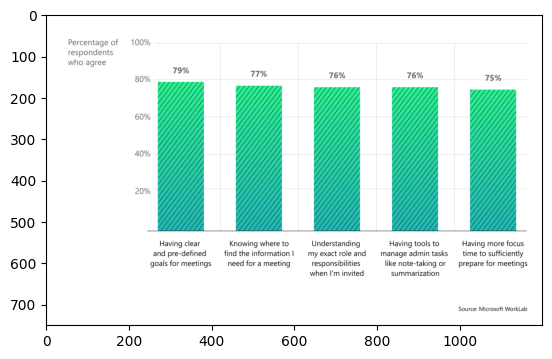

In [5]:
url = "https://assets-c4akfrf5b4d3f4b7.z01.azurefd.net/assets/2024/04/BMDataViz_661fb89f3845e.png" 
image = Image.open(requests.get(url, stream=True).raw) 

# Display the image
plt.imshow(image)

In [7]:
messages = [ 
    {"role": "user", "content": "<|image_1|>\nWhat is shown in this image?"}, 
    {"role": "assistant", "content": "The chart displays the percentage of respondents who agree with various statements about their preparedness for meetings. It shows five categories: 'Having clear and pre-defined goals for meetings', 'Knowing where to find the information I need for a meeting', 'Understanding my exact role and responsibilities when I'm invited', 'Having tools to manage admin tasks like note-taking or summarization', and 'Having more focus time to sufficiently prepare for meetings'. Each category has an associated bar indicating the level of agreement, measured on a scale from 0% to 100%."}, 
    {"role": "user", "content": "Provide insightful questions to spark discussion."} 
] 

prompt = processor.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

inputs = processor(prompt, [image], return_tensors="pt").to("cpu:0") 

In [8]:
generation_args = { 
    "max_new_tokens": 500, 
    "temperature": 0.0, 
    "do_sample": False, 
} 

generate_ids = model.generate(**inputs, eos_token_id=processor.tokenizer.eos_token_id, **generation_args) 

# remove input tokens 
generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
response = processor.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0] 

print(response)

c:\Users\aksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\generation\configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.
C:\Users\aksha\.cache\huggingface\modules\transformers_modules\microsoft\Phi-3-vision-128k-instruct\6065b7a1a412feff7ac023149f65358b71334984\image_embedding_phi3_v.py:197: UserWarning: Phi-3-V modifies `input_ids` in-place and the tokens indicating images will be removed after model forward. If your workflow requires multiple forward passes on the same `input_ids`, please make a copy of `input_ids` before passing it to the model.
  warnings.warn(


KeyboardInterrupt: 

# **Reference**

- https://huggingface.co/microsoft/Phi-3-vision-128k-instruct